In [63]:
import pandas as pd 
import numpy as np
from datetime import datetime, timedelta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [82]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','dayofweek','is_weekend','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '46.246.8.21']
data.tail(300)

,date,indicator,seen
22011,2025-04-20,23.26.221.24,0
22012,2025-04-20,23.26.221.26,0
22013,2025-04-20,46.246.8.46,0
22014,2025-04-20,46.246.8.56,0
22015,2025-04-20,46.246.8.96,0
...,...,...,...
22306,2025-04-21,107.180.119.251,0
22307,2025-04-21,190.92.174.36,0
22308,2025-04-21,192.124.249.112,0
22309,2025-04-21,66.132.159.247,0


In [83]:
# Ensure the data is sorted by 'indicator' and 'date'
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)

# Add 'dayofweek' column (0 = Monday, 6 = Sunday)
data['dayofweek'] = data['date'].dt.dayofweek

# Add 'isweekend' column (True if Saturday or Sunday, else False)
data['isweekend'] = data['dayofweek'].apply(lambda x: x >= 5)

# Add a column for "days since last seen"
data['days_since_last_seen'] = data.groupby('indicator')['date'].diff().dt.days

# Fill NaN values (e.g., for the first occurrence of each indicator) with 0
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

# Add exponentially weighted mean of past activity (ewm_seen)
data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)

# Add rolling count of 'seen == 1' in the last 3 days (seen_count_last_3)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)

In [84]:
data['date'] = pd.to_datetime(data['date'])
test_date = data[data['date'] == '2025-04-21 00:00:00']
#cutoff data 7 days ago and on
cutoff_date = datetime.now() - timedelta(days=7)
modelData = data[data['date'] <= cutoff_date]
modelData = modelData.sort_values(['indicator', 'date']).reset_index(drop=True)

In [85]:
modelData.tail()

,date,indicator,seen,dayofweek,isweekend,days_since_last_seen,ewm_seen,seen_count_last_3
20899,2025-04-10,www.shorturl.at/,1,3,False,1,0.943947,3.0
20900,2025-04-11,www.shorturl.at/,1,4,False,1,0.971973,3.0
20901,2025-04-12,www.shorturl.at/,0,5,True,1,0.485987,2.0
20902,2025-04-13,www.shorturl.at/,0,6,True,1,0.242993,1.0
20903,2025-04-14,www.shorturl.at/,1,0,False,1,0.621497,1.0


In [86]:
test_date

,date,indicator,seen,dayofweek,isweekend,days_since_last_seen,ewm_seen,seen_count_last_3
110,2025-04-21,102.129.153.158,0,0,False,1,2.980234e-08,0.0
221,2025-04-21,102.129.153.43,0,0,False,1,1.776359e-15,0.0
332,2025-04-21,102.129.153.71,0,0,False,1,3.125000e-02,0.0
443,2025-04-21,102.165.16.161,0,0,False,1,2.446249e-04,0.0
554,2025-04-21,104.160.6.2,0,0,False,1,9.094947e-13,0.0
...,...,...,...,...,...,...,...,...
21866,2025-04-21,international.standardbank.com/,0,0,False,1,4.038968e-28,0.0
21977,2025-04-21,pub.marq.com/,0,0,False,1,2.491623e-04,0.0
22088,2025-04-21,realinvestmentadvice.com/,0,0,False,1,5.226135e-04,0.0
22199,2025-04-21,www.emergencylighting.com/,0,0,False,1,2.541202e-21,0.0


In [87]:
# Reset index after groupby operations
modelData['ewm_seen'] = modelData.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)
modelData['seen_count_last_3'] = modelData.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)

In [89]:
# Generate sequences with 15 lags, including all features
sequences = []
window = 15

for indicator, group in modelData.groupby("indicator"):
    group = group.sort_values("date").reset_index(drop=True)
    for i in range(len(group) - window):
        seq = group.iloc[i:i+window][['seen', 'dayofweek', 'isweekend', 'days_since_last_seen', 'ewm_seen', 'seen_count_last_3']].values
        label = group['seen'].iloc[i+window]
        date = group['date'].iloc[i+window]  # Get the date corresponding to the label
        sequences.append({
            **{f'lag_{j+1}_seen': val[0] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_dayofweek': val[1] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_isweekend': val[2] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_days_since_last_seen': val[3] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen': val[4] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_seen_count_last_3': val[5] for j, val in enumerate(seq)},
            'label': label,
            'indicator': indicator,
            'date': date  # Add the date here
        })

# Convert sequences to a DataFrame
sequence_df = pd.DataFrame(sequences)

# Save the DataFrame to a CSV file
sequence_df.to_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv", index=False)

In [95]:
sequence_df.head(500)

,lag_1_seen,lag_2_seen,lag_3_seen,lag_4_seen,lag_5_seen,lag_6_seen,lag_7_seen,lag_8_seen,lag_9_seen,lag_10_seen,...,lag_9_seen_count_last_3,lag_10_seen_count_last_3,lag_11_seen_count_last_3,lag_12_seen_count_last_3,lag_13_seen_count_last_3,lag_14_seen_count_last_3,lag_15_seen_count_last_3,label,indicator,date
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,102.129.153.158,2025-01-16
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,102.129.153.158,2025-01-17
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,102.129.153.158,2025-01-18
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,102.129.153.158,2025-01-19
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,102.129.153.158,2025-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,1,0,0,0,1,...,0.0,1.0,2.0,2.0,1.0,0.0,1.0,1,104.18.32.191,2025-03-07
496,0,0,0,0,1,0,0,0,1,1,...,1.0,2.0,2.0,1.0,0.0,1.0,2.0,0,104.18.32.191,2025-03-08
497,0,0,0,1,0,0,0,1,1,0,...,2.0,2.0,1.0,0.0,1.0,2.0,2.0,0,104.18.32.191,2025-03-09
498,0,0,1,0,0,0,1,1,0,0,...,2.0,1.0,0.0,1.0,2.0,2.0,1.0,0,104.18.32.191,2025-03-10


In [91]:
# Check data types
print(modelData.dtypes)

# Convert 'seen' column to numeric if necessary
modelData['seen'] = pd.to_numeric(modelData['seen'], errors='coerce')

# Ensure 'date' column is in datetime format
modelData['date'] = pd.to_datetime(modelData['date'], errors='coerce')

date                    datetime64[ns]
indicator                       object
seen                             int64
dayofweek                        int32
isweekend                         bool
days_since_last_seen             int64
ewm_seen                       float64
seen_count_last_3              float64
dtype: object


In [92]:
# Load processed data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv")
X = df.drop(columns=['label', 'indicator']).values
y = df['label'].values
indicators = df['indicator'].values

X = df.drop(columns=['label', 'indicator'])

# Strip column names (just in case)
X.columns = X.columns.str.strip()

# Coerce all data to numeric, fill missing, then convert to numpy
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32).values

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test, ind_train, ind_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42
)

# Define an improved LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower LR for better convergence
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Add early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop]
)


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 107s 69ms/step - accuracy: 0.7517 - loss: 0.5545 - val_accuracy: 0.9036 - val_loss: 0.2953
Epoch 2/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 97s 68ms/step - accuracy: 0.8933 - loss: 0.3400 - val_accuracy: 0.9085 - val_loss: 0.2760
Epoch 3/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 96s 67ms/step - accuracy: 0.8956 - loss: 0.3203 - val_accuracy: 0.9099 - val_loss: 0.2740
Epoch 4/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.8930 - loss: 0.3233 - val_accuracy: 0.9067 - val_loss: 0.2773
Epoch 5/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.8934 - loss: 0.3180 - val_accuracy: 0.9102 - val_loss: 0.2904
Epoch 6/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.8972 - loss: 0.3143 - val_accuracy: 0.9099 - val_loss: 0.2772
Epoch 7/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - accuracy: 0.8989 - loss: 0.3058 - val_accuracy: 0.9050 - val_loss: 0.3059
Epoch 8/60
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9026 

In [94]:
# Predict on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Group by indicator and calculate stats
from collections import defaultdict

indicator_stats = defaultdict(lambda: {'true': [], 'pred': [], 'prob': []})
for i, ind in enumerate(ind_test):
    indicator_stats[ind]['true'].append(y_test[i])
    indicator_stats[ind]['pred'].append(y_pred[i])
    indicator_stats[ind]['prob'].append(y_pred_prob[i])

# Build summary
summary = []
for ind, vals in indicator_stats.items():
    acc = np.mean(np.array(vals['true']) == np.array(vals['pred']))
    avg_prob = np.mean(vals['prob'])
    summary.append({
        'Date': date,
        'indicator': ind,
        'accuracy': round(acc, 3),
        'avg_predicted_probability': round(avg_prob, 3),
        'samples': len(vals['true']),
        'seen': test_date[test_date['indicator'] == ind]['seen'].values[0]
    })

results_df = pd.DataFrame(summary).sort_values(by='avg_predicted_probability', ascending=False)
results_df.head(500)


112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


,Date,indicator,accuracy,avg_predicted_probability,samples,seen
106,2025-04-14,34.160.111.145,0.944,0.829,18,1
97,2025-04-14,185.230.63.171,0.800,0.805,25,0
31,2025-04-14,172.240.108.68,0.882,0.795,17,0
129,2025-04-14,162.142.125.255,0.824,0.792,17,0
84,2025-04-14,162.142.125.247,0.812,0.782,16,1
...,...,...,...,...,...,...
90,2025-04-14,104.21.3.76,1.000,0.033,13,0
82,2025-04-14,20.48.204.4,1.000,0.033,16,0
158,2025-04-14,192.124.249.112,1.000,0.033,22,0
148,2025-04-14,190.92.174.48,1.000,0.033,16,0



=== Threshold Performance ===
Threshold 0.4: avg_reward=0.920, used 2543x
Threshold 0.5: avg_reward=0.892, used 93x
Threshold 0.6: avg_reward=0.807, used 322x
Threshold 0.7: avg_reward=0.792, used 620x


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


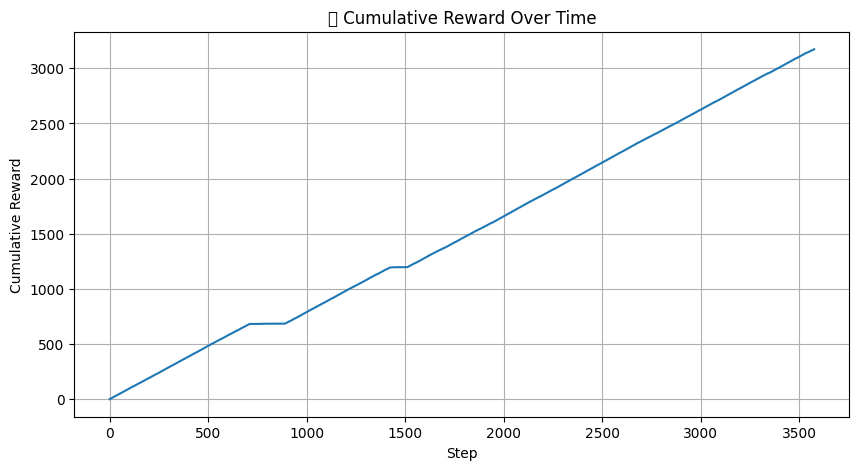

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


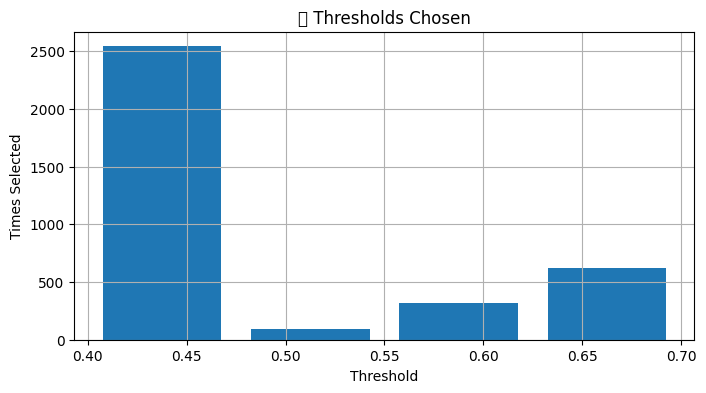

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Define threshold options (actions)
actions = [0.4, 0.5, 0.6, 0.7]

# Initialize tracking
rewards = np.zeros(len(actions))
counts = np.zeros(len(actions))
epsilon = 0.1  # 10% exploration

# Logging for plotting
reward_log = []
threshold_log = []

# Bandit logic
def choose_action():
    if np.random.rand() < epsilon:
        return np.random.choice(len(actions))  # explore
    else:
        return np.argmax(rewards / (counts + 1e-5))  # exploit

def update_rewards(action, reward):
    counts[action] += 1
    rewards[action] += reward

actual_outcomes = []
for i, prob in enumerate(y_pred_prob):
    action = choose_action()
    threshold = actions[action]

    indicator = indicators[i]  # match prediction to an indicator

    # Predict based on threshold
    prediction = 1 if prob > threshold else 0

    # ✅ Lookup today's truth
    seen_today = test_date[test_date['indicator'] == indicator]['seen']
    if seen_today.empty:
        actual = 0  # default if indicator wasn't seen at all
    else:
        actual = int(seen_today.values[0])

    # Reward based on actual outcome
    reward = 1 if prediction == actual else 0

    update_rewards(action, reward)
    reward_log.append(reward)
    threshold_log.append(actions[action])
    actual_outcomes.append({
        'indicator': indicator,
        'predicted_prob': prob,
        'threshold': threshold,
        'predicted': prediction,
        'actual': actual,
        'reward': reward
    })

# 📈 Print threshold stats
print("\n=== Threshold Performance ===")
avg_rewards = rewards / (counts + 1e-5)
for a, r, c in zip(actions, avg_rewards, counts):
    print(f"Threshold {a}: avg_reward={r:.3f}, used {int(c)}x")

# 📊 Plot cumulative reward over time
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(reward_log))
plt.title("🎯 Cumulative Reward Over Time")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()

# 📊 Plot threshold usage
plt.figure(figsize=(8, 4))
plt.hist(threshold_log, bins=len(actions), rwidth=0.8)
plt.title("🧠 Thresholds Chosen")
plt.xlabel("Threshold")
plt.ylabel("Times Selected")
plt.grid(True)
plt.show()


In [107]:
results_df = pd.DataFrame(actual_outcomes)
results_df[results_df['indicator'] == '102.129.153.43']


,indicator,predicted_prob,threshold,predicted,actual,reward
89,102.129.153.43,0.311456,0.7,0,0,1
90,102.129.153.43,0.067348,0.7,0,0,1
91,102.129.153.43,0.098165,0.7,0,0,1
92,102.129.153.43,0.220706,0.7,0,0,1
93,102.129.153.43,0.333839,0.7,0,0,1
...,...,...,...,...,...,...
173,102.129.153.43,0.032977,0.7,0,0,1
174,102.129.153.43,0.032966,0.7,0,0,1
175,102.129.153.43,0.161444,0.7,0,0,1
176,102.129.153.43,0.032970,0.7,0,0,1
